<a href="https://colab.research.google.com/github/miller00315/ciencia-de-dados/blob/master/deep_learning_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regressão linear

In [ ]:
xs = [1, 2, 3, 4, 5, 6, 7, 8]

ys = [2.9, 3.4, 4.9, 4.7, 6.2, 6.9, 7.3, 8.6]

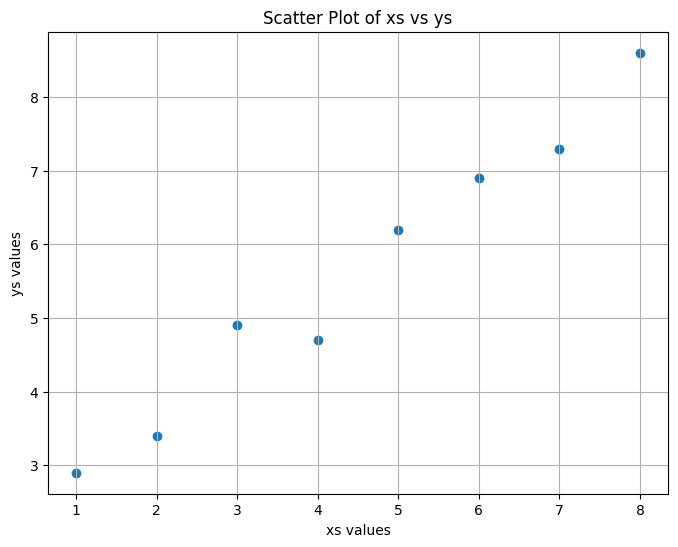

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(xs, ys)
plt.title('Scatter Plot of xs vs ys')
plt.xlabel('xs values')
plt.ylabel('ys values')
plt.grid(True)
plt.show()

In [ ]:
w, b = 0.0, 0.0 #weight, bias
lr = 0.01 #learning rate

In [ ]:
for epoch in range(1000):
  dw, db = 0.0, 0.0
  for x, y in zip(xs, ys):
    pred = w * x + b
    err = y - pred
    dw += 2 * err * x /len(xs)
    db += 2 * err /len(xs)
  w += lr * dw
  b += lr * db

In [ ]:
w

0.8023850769736849

In [ ]:
b

1.995082123583895

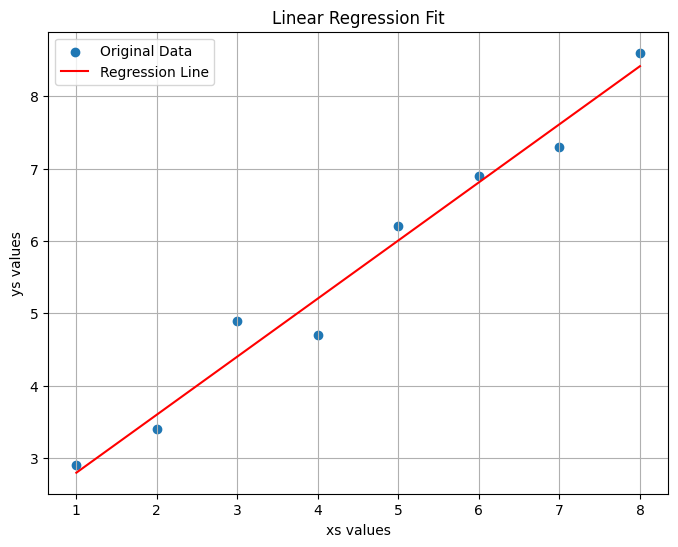

In [ ]:
import matplotlib.pyplot as plt

# Calculate predicted y values using the learned w and b
y_pred = [w * x + b for x in xs]

plt.figure(figsize=(8, 6))
plt.scatter(xs, ys, label='Original Data') # Plot original data points
plt.plot(xs, y_pred, color='red', label='Regression Line') # Plot the regression line
plt.title('Linear Regression Fit')
plt.xlabel('xs values')
plt.ylabel('ys values')
plt.grid(True)
plt.legend()
plt.show()

#Neurônio

In [12]:
xs = [[1, 2], [2, 1], [2, 3], [3, 2], [6, 7], [7, 6], [7, 8], [8, 7]]

ys = [0, 0, 0, 0, 1, 1, 1, 1]

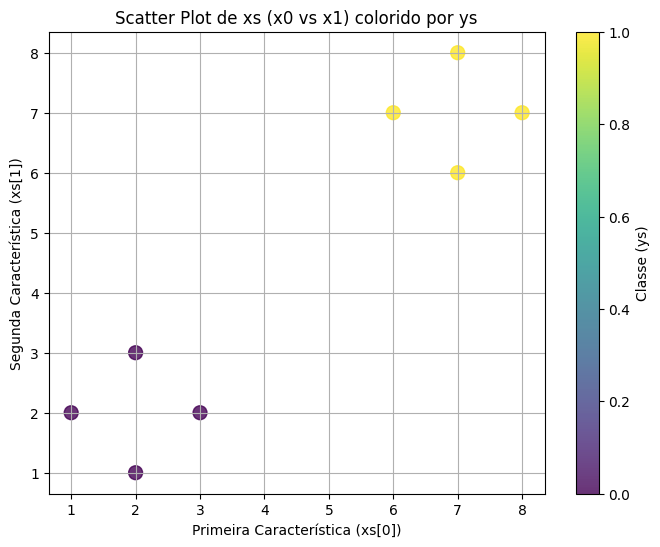

In [16]:
import matplotlib.pyplot as plt

# Extrair as duas dimensões de xs
x0_coords = [x[0] for x in xs]
x1_coords = [x[1] for x in xs]

plt.figure(figsize=(8, 6))
plt.scatter(x0_coords, x1_coords, c=ys, cmap='viridis', s=100, alpha=0.8)
plt.title('Scatter Plot de xs (x0 vs x1) colorido por ys')
plt.xlabel('Primeira Característica (xs[0])')
plt.ylabel('Segunda Característica (xs[1])')
plt.colorbar(label='Classe (ys)')
plt.grid(True)
plt.show()

In [13]:
w1, w2, b = 0.0, 0.0, 0.0 #weights and bias
lr = 0.01 #learning rate

In [14]:
from math import exp

for epoch in range(1000):
  for x, y in zip(xs, ys):
    z = w1 * x[0] + w2 * x[1] + b

    p = 1 / (1 + exp(-z))

    err = p - y

    w1 -= lr * err * x[0]
    w2 -= lr * err * x[1]
    b -= lr * err

/tmp/ipykernel_6017/2244699119.py:38: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, p_grid, levels=[0.5], colors='k', linestyles='--', linewidths=2, label='Fronteira de Decisão (p=0.5)')


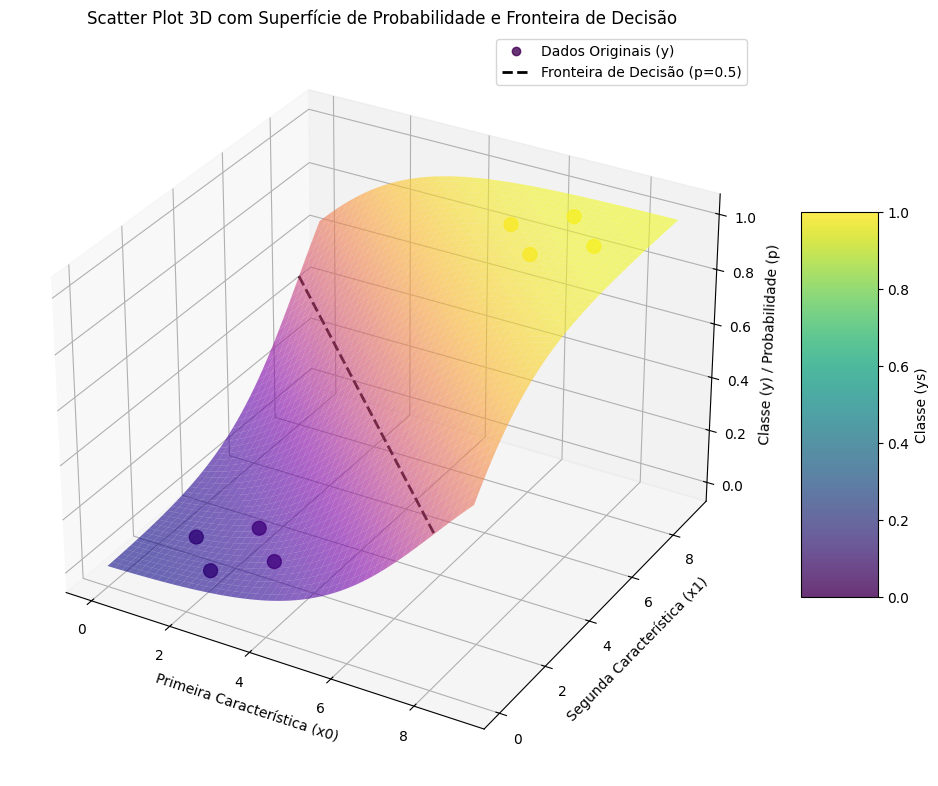

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Função sigmoide para operar com arrays NumPy
def sigmoid_np(x_val):
    return 1 / (1 + np.exp(-x_val))

# Extrair as duas dimensões de xs e ys como arrays NumPy
x0_coords = np.array([x[0] for x in xs])
x1_coords = np.array([x[1] for x in xs])
ys_array = np.array(ys)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Plotar os dados de treinamento em 3D
# x0 no eixo X, x1 no eixo Y, e a classe (ys) no eixo Z
scatter = ax.scatter(x0_coords, x1_coords, ys_array, c=ys_array, cmap='viridis', s=100, alpha=0.8, label='Dados Originais (y)')

# 2. Plotar a superfície de probabilidade (decision surface)
# Criar uma grade de pontos para x0 e x1 para cobrir o espaço dos dados
x_min, x_max = np.min(x0_coords) - 1, np.max(x0_coords) + 1
y_min, y_max = np.min(x1_coords) - 1, np.max(x1_coords) + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

# Calcular os valores de 'z' (entrada para a função sigmoide) para cada ponto da grade
z_grid_raw = w1 * xx + w2 * yy + b
# Calcular a probabilidade 'p' para cada ponto da grade
p_grid = sigmoid_np(z_grid_raw)

# Plotar a superfície de probabilidade como uma superfície em 3D
ax.plot_surface(xx, yy, p_grid, cmap='plasma', alpha=0.6)

# 3. Plotar a fronteira de decisão (onde p=0.5) como um contorno na superfície
# Isso é equivalente a onde z_grid_raw = 0
ax.contour(xx, yy, p_grid, levels=[0.5], colors='k', linestyles='--', linewidths=2, label='Fronteira de Decisão (p=0.5)')

ax.set_title('Scatter Plot 3D com Superfície de Probabilidade e Fronteira de Decisão')
ax.set_xlabel('Primeira Característica (x0)')
ax.set_ylabel('Segunda Característica (x1)')
ax.set_zlabel('Classe (y) / Probabilidade (p)')

# Adicionar uma legenda para a colorbar do scatter plot
plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5, label='Classe (ys)')

# Criação de um proxy para a linha de decisão para a legenda
proxy_line = plt.Line2D([0], [0], linestyle='--', color='k', linewidth=2)
ax.legend([scatter.legend_elements()[0][0], proxy_line], ['Dados Originais (y)', 'Fronteira de Decisão (p=0.5)'], loc='best')

plt.show()

# 3 neurônios

In [19]:
from math import exp

data = [(0, 0, 0), (0, 1, 1), (1, 0, 1), (1, 1, 0)]

w = [.3, -.8, .5, -.2, 9, .1, .7, -.6, .2]

lr = 0.5

sig = lambda x: 1 / (1 + exp(-x))


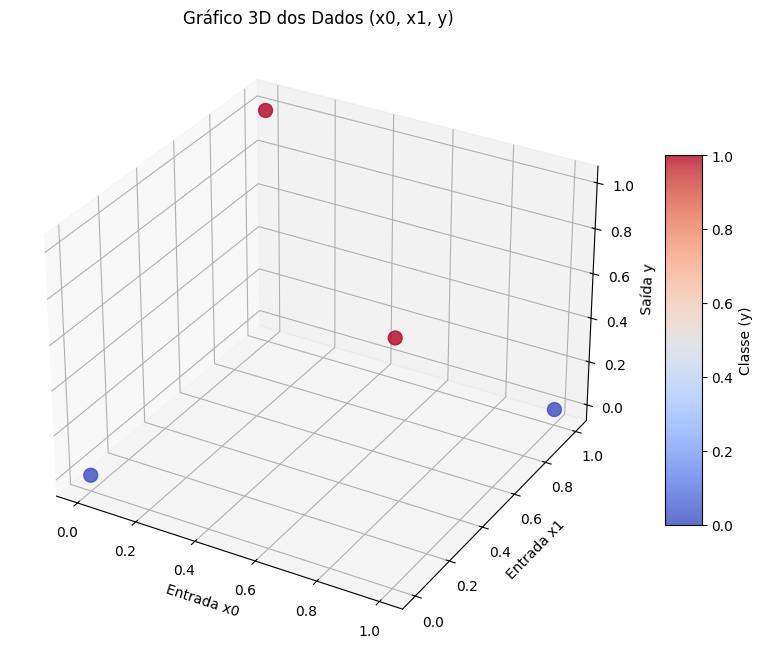

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extrair as coordenadas do 'data'
x0_data = np.array([d[0] for d in data])
x1_data = np.array([d[1] for d in data])
y_data = np.array([d[2] for d in data])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotar os pontos de dados em 3D
scatter = ax.scatter(x0_data, x1_data, y_data, c=y_data, cmap='coolwarm', s=100, alpha=0.8)

ax.set_title('Gráfico 3D dos Dados (x0, x1, y)')
ax.set_xlabel('Entrada x0')
ax.set_ylabel('Entrada x1')
ax.set_zlabel('Saída y')

# Adicionar uma legenda para a colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=10)
cbar.set_label('Classe (y)')

plt.show()

In [22]:
for epoch in range(3000):
  for x0, x1, y in data:

    a = sig(w[0] * x0 +  w[1] * x1 + w[2])
    b = sig(w[3] * x0 +  w[4] * x1 + w[5])
    p = sig(w[6] * a +  w[7] * b + w[8])

    err = p - y

    ga = err * w[6] * a * (1 - a)
    gb = err * w[7] * b * (1 - b)

    grad = [ga * x0, ga * x1, ga, gb * x0, gb * x1, gb, err * a, err * b, err]

    for i in range(len(w)):
      w[i] -= lr * grad[i]



/tmp/ipykernel_6017/1468338668.py:46: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, p_grid, levels=[0.5], colors='red', linestyles='-', linewidths=3, zorder=10, label='Fronteira de Decisão (p=0.5)')


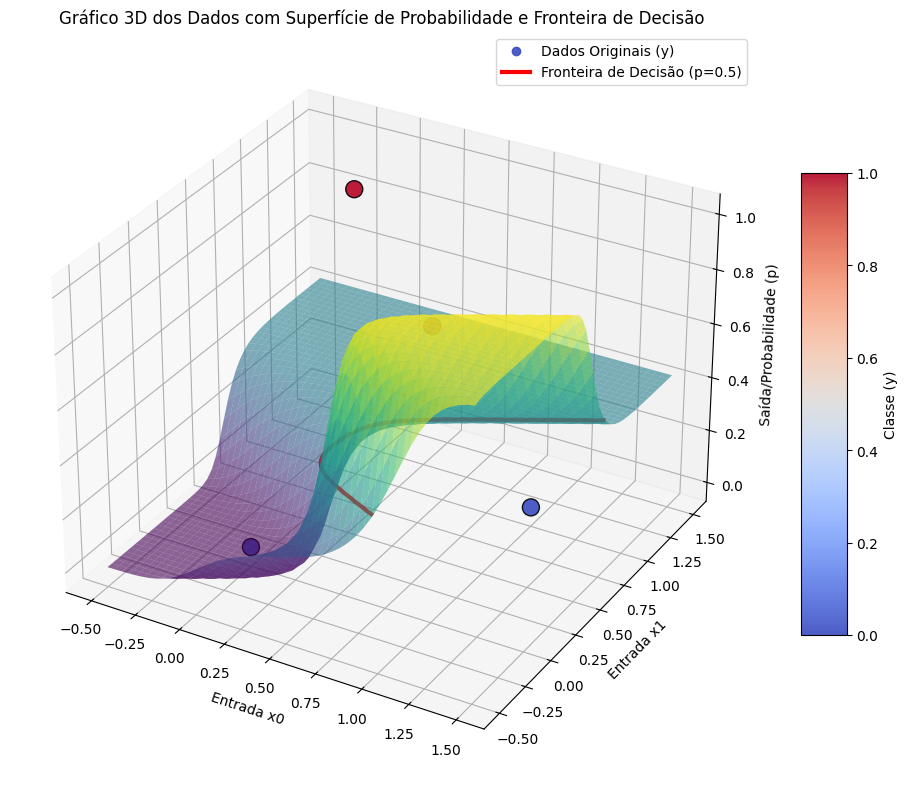

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# A função sigmoide foi definida anteriormente como 'sig' na célula Jruo2v8CI3Hu.
# Re-definindo para garantir que esteja disponível neste contexto ou se a célula anterior não foi executada.
# Se 'sig' já estiver no ambiente, esta linha não terá efeito colateral.
# from math import exp # Já importado, mas np.exp é melhor para arrays
def sig_np(x):
    return 1 / (1 + np.exp(-x))

# Extrair as coordenadas do 'data'
x0_data = np.array([d[0] for d in data])
x1_data = np.array([d[1] for d in data])
y_data = np.array([d[2] for d in data])

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Plotar os dados de treinamento em 3D
scatter = ax.scatter(x0_data, x1_data, y_data, c=y_data, cmap='coolwarm', s=150, edgecolors='k', alpha=0.9, label='Dados Originais (y)')

# 2. Plotar a superfície de probabilidade (decision surface) da rede neural
# Criar uma grade de pontos para x0 e x1 para cobrir o espaço dos dados
x_min, x_max = -0.5, 1.5 # Ajustado para o range de data (0, 1)
y_min, y_max = -0.5, 1.5 # Ajustado para o range de data (0, 1)
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

# Calcular as saídas da rede neural para cada ponto da grade
# As entradas x0 e x1 são as variáveis de meshgrid xx e yy
# Certifique-se que 'w' é acessível (assumindo que foi atualizado e está no escopo global)

# Camada escondida 1
a_grid = sig_np(w[0] * xx +  w[1] * yy + w[2])
# Camada escondida 2
b_grid = sig_np(w[3] * xx +  w[4] * yy + w[5])
# Saída final
p_grid = sig_np(w[6] * a_grid +  w[7] * b_grid + w[8])

# Plotar a superfície de probabilidade como uma superfície em 3D
ax.plot_surface(xx, yy, p_grid, cmap='viridis', alpha=0.6)

# 3. Plotar a fronteira de decisão (onde p=0.5) como um contorno na superfície
# Isso é a 'linha' em 3D onde a superfície de probabilidade cruza o plano z=0.5
ax.contour(xx, yy, p_grid, levels=[0.5], colors='red', linestyles='-', linewidths=3, zorder=10, label='Fronteira de Decisão (p=0.5)')

ax.set_title('Gráfico 3D dos Dados com Superfície de Probabilidade e Fronteira de Decisão')
ax.set_xlabel('Entrada x0')
ax.set_ylabel('Entrada x1')
ax.set_zlabel('Saída/Probabilidade (p)')

# Adicionar uma legenda para a colorbar do scatter plot
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=10)
cbar.set_label('Classe (y)')

# Criação de um proxy para a linha de decisão para a legenda
proxy_line = plt.Line2D([0], [0], linestyle='-', color='red', linewidth=3)
ax.legend([scatter.legend_elements()[0][0], proxy_line], ['Dados Originais (y)', 'Fronteira de Decisão (p=0.5)'], loc='best')

plt.show()